# AI304 Unsupervised Learning Lab
## Notebook 2: Feature Engineering

In [1]:
# ─────────────────────────────────────────────
# Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("Libraries imported.")

Libraries imported.


In [2]:
# ─────────────────────────────────────────────
# Load cleaned dataset produced by Notebook 1
# parse_dates + index_col ensures the datetime index is restored
# ─────────────────────────────────────────────
df = pd.read_csv("cleaned_power_data.csv", parse_dates=True, index_col='datetime')

print(f"Loaded shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Loaded shape: (2049280, 7)
Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# ─────────────────────────────────────────────
# Feature 1: Daily statistics of Global Active Power
# mean  → average daily consumption level
# max   → peak consumption (load spike)
# min   → baseline / idle consumption
# std   → variability / irregularity of usage
# ─────────────────────────────────────────────
power_features = df['Global_active_power'].resample('D').agg(
    mean_power='mean',
    max_power='max',
    min_power='min',
    std_power='std'
)

print(f"Power features shape: {power_features.shape}")
power_features.head()

Power features shape: (1442, 4)


,mean_power,max_power,min_power,std_power
datetime,,,,
2006-12-16,3.053475,7.706,0.284,1.026338
2006-12-17,2.354486,7.064,0.206,1.205795
2006-12-18,1.530435,6.158,0.202,1.005074
2006-12-19,1.157079,7.840,0.194,1.237602
2006-12-20,1.545658,5.988,0.202,1.320968


In [4]:
# ─────────────────────────────────────────────
# Feature 2: Peak-to-Average Ratio (Load Factor)
# A high ratio indicates spiky, unpredictable usage.
# A low ratio indicates steady, consistent consumption.
# This is a key metric in energy behaviour analysis.
# ─────────────────────────────────────────────
power_features['peak_to_avg_ratio'] = (
    power_features['max_power'] / power_features['mean_power'].replace(0, np.nan)
)

print("Peak-to-average ratio added.")

Peak-to-average ratio added.


In [5]:
# ─────────────────────────────────────────────
# Feature 3: Daily sub-metering totals
# Sub_metering_1 → kitchen (dishwasher, microwave, oven)
# Sub_metering_2 → laundry (washing machine, dryer, fridge)
# Sub_metering_3 → HVAC / electric water heater
# These help distinguish household activity archetypes.
# ─────────────────────────────────────────────
sub_features = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('D').mean()
sub_features.columns = ['avg_kitchen', 'avg_laundry', 'avg_hvac']

print(f"Sub-metering features shape: {sub_features.shape}")
sub_features.head()

Sub-metering features shape: (1442, 3)


,avg_kitchen,avg_laundry,avg_hvac
datetime,,,
2006-12-16,0.000000,1.378788,12.439394
2006-12-17,1.411806,2.907639,9.264583
2006-12-18,0.738194,1.820139,9.734722
2006-12-19,0.582639,5.279167,4.303472
2006-12-20,0.000000,1.838889,9.765972


In [6]:
# ─────────────────────────────────────────────
# Feature 4: Voltage statistics
# Daily mean voltage can reflect grid quality and
# correlate with overall consumption patterns.
# ─────────────────────────────────────────────
volt_features = df['Voltage'].resample('D').agg(
    mean_voltage='mean',
    std_voltage='std'
)

print(f"Voltage features shape: {volt_features.shape}")

Voltage features shape: (1442, 2)


In [7]:
# ─────────────────────────────────────────────
# Step: Merge all feature groups into one DataFrame
# We align on the daily datetime index.
# ─────────────────────────────────────────────
daily_features = pd.concat([power_features, sub_features, volt_features], axis=1)

# Drop any days with NaN values (e.g., first/last day with partial data)
daily_features = daily_features.dropna()

print(f"Combined feature matrix shape: {daily_features.shape}")
daily_features.head()

Combined feature matrix shape: (1433, 10)


,mean_power,max_power,min_power,std_power,peak_to_avg_ratio,avg_kitchen,avg_laundry,avg_hvac,mean_voltage,std_voltage
datetime,,,,,,,,,,
2006-12-16,3.053475,7.706,0.284,1.026338,2.523682,0.000000,1.378788,12.439394,236.243763,2.922896
2006-12-17,2.354486,7.064,0.206,1.205795,3.000230,1.411806,2.907639,9.264583,240.087028,4.051467
2006-12-18,1.530435,6.158,0.202,1.005074,4.023693,0.738194,1.820139,9.734722,241.231694,3.719576
2006-12-19,1.157079,7.840,0.194,1.237602,6.775682,0.582639,5.279167,4.303472,241.999313,3.069492
2006-12-20,1.545658,5.988,0.202,1.320968,3.874077,0.000000,1.838889,9.765972,242.308062,3.345704


In [8]:
# ─────────────────────────────────────────────
# Feature 5: Day-of-week and Weekend flag
# Weekday (0=Mon … 4=Fri) vs weekend (5=Sat, 6=Sun)
# captures behavioural differences in usage patterns.
# ─────────────────────────────────────────────
daily_features['day_of_week'] = daily_features.index.dayofweek
daily_features['is_weekend'] = (daily_features['day_of_week'] >= 5).astype(int)

print("Day-of-week and weekend flag added.")
daily_features[['day_of_week', 'is_weekend']].value_counts().sort_index()

Day-of-week and weekend flag added.


day_of_week  is_weekend
0            0             205
1            0             206
2            0             204
3            0             205
4            0             205
5            1             205
6            1             203
Name: count, dtype: int64

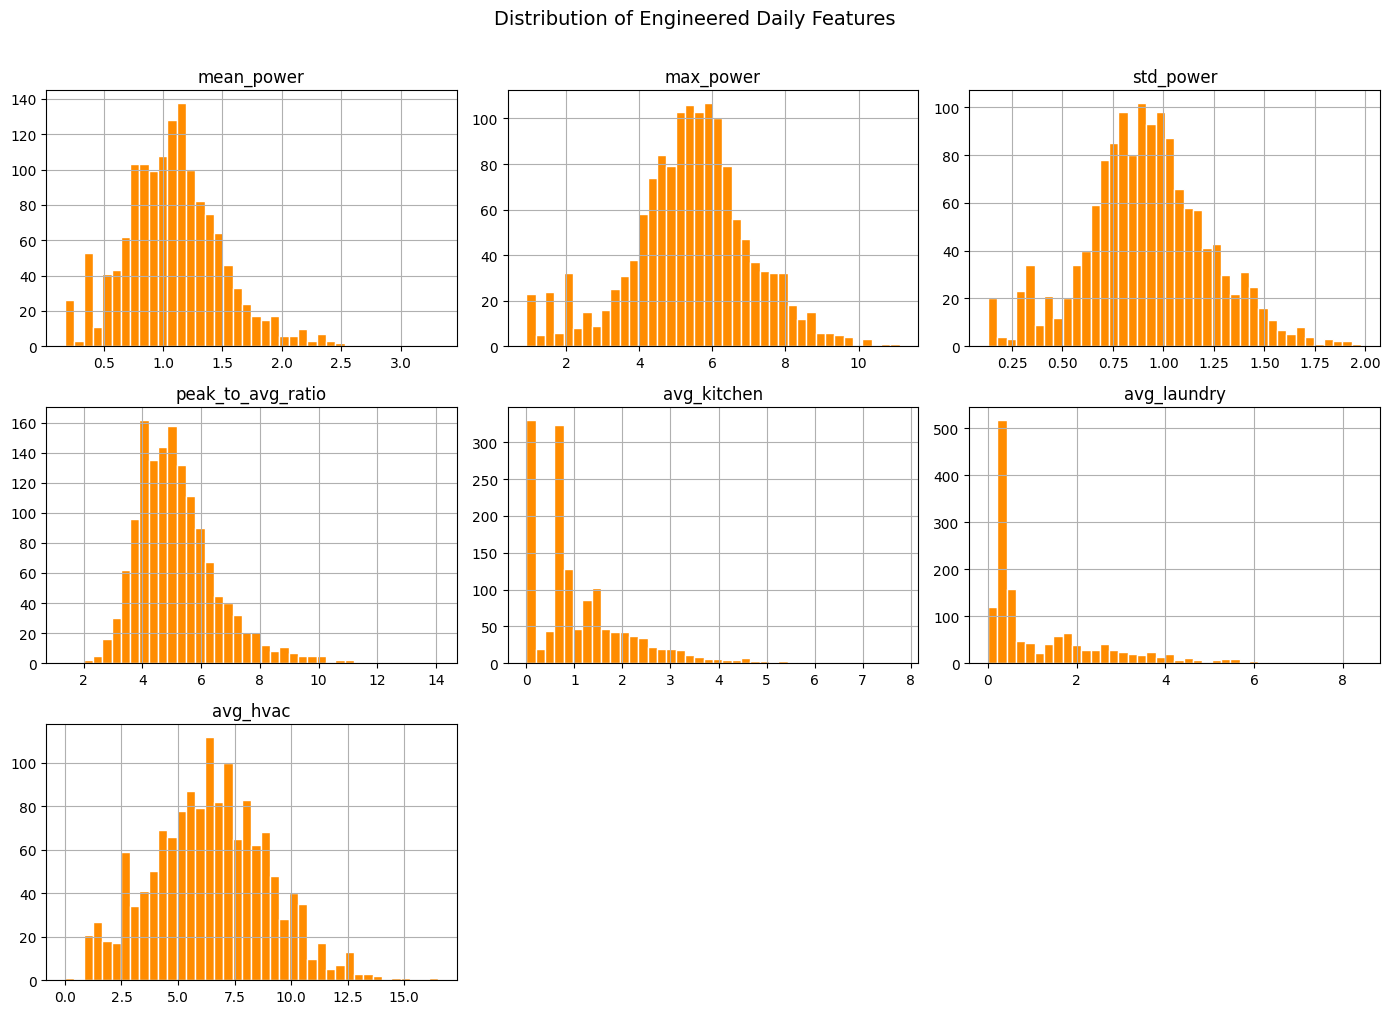

In [9]:
# ─────────────────────────────────────────────
# Visualise engineered features: distributions
# Helps confirm the features are well-behaved for clustering
# ─────────────────────────────────────────────
feature_cols = [
    'mean_power', 'max_power', 'std_power',
    'peak_to_avg_ratio', 'avg_kitchen', 'avg_laundry', 'avg_hvac'
]

daily_features[feature_cols].hist(bins=40, figsize=(14, 10), color='darkorange', edgecolor='white')
plt.suptitle("Distribution of Engineered Daily Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

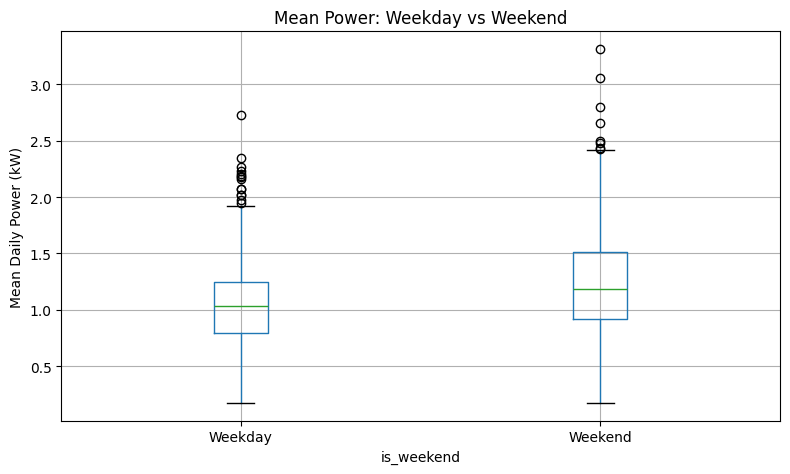

In [10]:
# ─────────────────────────────────────────────
# Visualise: Weekday vs Weekend power usage
# Box plots reveal if weekends have higher/lower consumption
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
daily_features.boxplot(column='mean_power', by='is_weekend', ax=ax)
ax.set_xticklabels(['Weekday', 'Weekend'])
ax.set_title("Mean Power: Weekday vs Weekend")
ax.set_ylabel("Mean Daily Power (kW)")
plt.suptitle('')
plt.tight_layout()
plt.show()

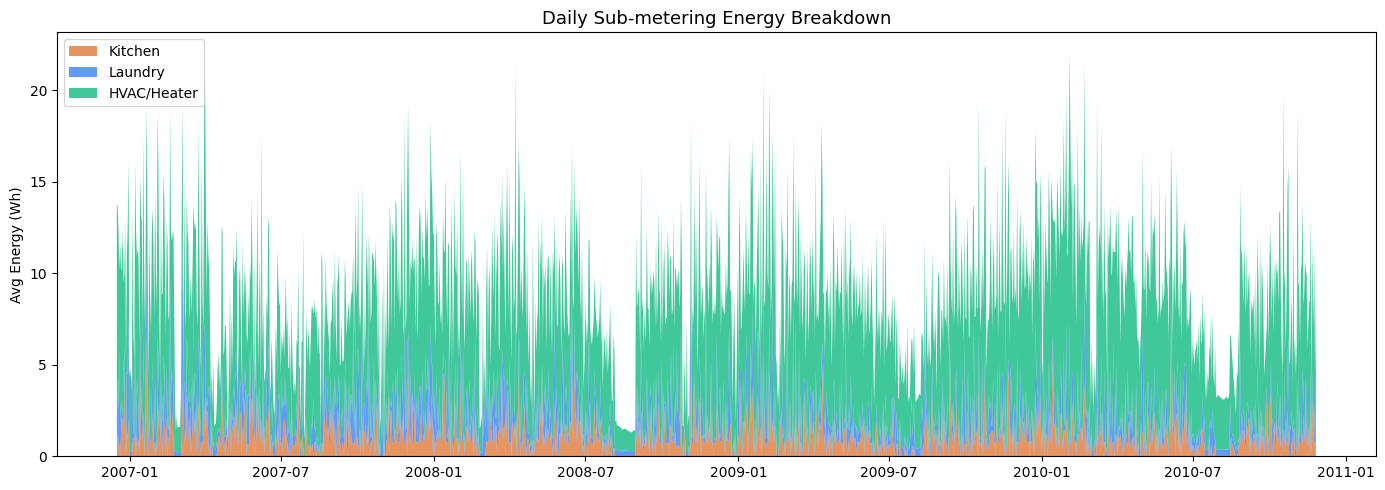

In [11]:
# ─────────────────────────────────────────────
# Visualise: Sub-metering breakdown over time
# Stacked area chart shows which zones consume the most energy
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.stackplot(
    daily_features.index,
    daily_features['avg_kitchen'],
    daily_features['avg_laundry'],
    daily_features['avg_hvac'],
    labels=['Kitchen', 'Laundry', 'HVAC/Heater'],
    alpha=0.8,
    colors=['#e07b39', '#3b82f6', '#10b981']
)

ax.set_title("Daily Sub-metering Energy Breakdown", fontsize=13)
ax.set_ylabel("Avg Energy (Wh)")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────
# Feature Scaling using StandardScaler
# Clustering algorithms (especially distance-based) are
# sensitive to feature scale. We standardise so that
# each feature has mean=0 and std=1.
# We scale only the numeric clustering features (not day_of_week/is_weekend)
# ─────────────────────────────────────────────
cluster_feature_cols = [
    'mean_power', 'max_power', 'min_power', 'std_power',
    'peak_to_avg_ratio', 'avg_kitchen', 'avg_laundry', 'avg_hvac',
    'mean_voltage', 'std_voltage'
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(daily_features[cluster_feature_cols])

print(f"Scaled feature matrix shape: {scaled_data.shape}")
print(f"Mean of scaled features (should be ~0): {scaled_data.mean(axis=0).round(4)}")
print(f"Std of scaled features  (should be ~1): {scaled_data.std(axis=0).round(4)}")

Scaled feature matrix shape: (1433, 10)
Mean of scaled features (should be ~0): [-0. -0.  0.  0.  0. -0.  0.  0.  0. -0.]
Std of scaled features  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
# ─────────────────────────────────────────────
# Save feature-engineered data for Notebook 3
# We save both the original daily_features (for interpretation)
# and the scaled_data array (for clustering).
# ─────────────────────────────────────────────
daily_features.to_csv("daily_features.csv")
np.save("scaled_data.npy", scaled_data)

print("Saved: 'daily_features.csv' and 'scaled_data.npy'")

Saved: 'daily_features.csv' and 'scaled_data.npy'
